# Word2Vec

## Setup

In [65]:
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
import plotly_express as px
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style='ticks')

F1_path = 'data/F1'
F3_path = 'data/F3'
F4_path = 'data/F4'
F5_path = 'data/F5'
os.makedirs(F5_path+"/word2vec/figures", exist_ok=True)

In [66]:
OHCO = ['work_id','part_num','chap_num','para_num','sent_num','token_num']
BAG = OHCO[:4]

VECTOR_SIZE = 100
WINDOW = 5
MIN_COUNT = 25
EPOCHS = 50
SEED = 42

LIB = pd.read_csv(f"{F1_path}/LIB.csv", index_col=OHCO[0])
TOKEN = pd.read_csv(f"{F4_path}/TOKEN.csv", index_col=OHCO,
                    keep_default_na=False, na_values=[])

print(f"TOKEN: {len(TOKEN):,} tokens")

TOKEN: 283,960 tokens


## Build corpus

In [67]:
VOCAB = pd.read_csv(f"{F4_path}/VOCAB.csv", index_col='term_id',
                    keep_default_na=False, na_values=[])
stop_terms = set(VOCAB[VOCAB.stop == 1].term_str.tolist())

TOKEN_filtered = TOKEN[
    (TOKEN.term_str != '') &
    (~TOKEN.term_str.isin(stop_terms))
]

print(f"Tokens after filter: {len(TOKEN_filtered):,}")

Tokens after filter: 136,090


In [68]:
corpus = TOKEN_filtered.groupby(BAG).term_str.apply(lambda x: x.tolist()).tolist()

print(f"Paragraphs in corpus: {len(corpus):,}")
print(f"Sample: {corpus[100][:20]}")

Paragraphs in corpus: 3,578
Sample: ['lastly', 'proposed', 'singular', 'advantage', 'abolishing', 'christianity', 'much', 'contribute', 'uniting', 'protestants', 'enlarging', 'terms', 'communion', 'take', 'sorts', 'dissenters', 'shut', 'pale', 'upon', 'account']


In [69]:
model = Word2Vec(
    corpus,
    vector_size=VECTOR_SIZE,
    window=WINDOW,
    min_count=MIN_COUNT,
    workers=4,
    epochs=EPOCHS,
    seed=SEED,
    sg = 1,
    sample = 1e-4
)

print(f"Vocabulary size: {len(model.wv.key_to_index):,}")

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocabulary size: 1,088


## Build coordinates

In [70]:
vocab_terms = list(model.wv.key_to_index.keys())
coords = pd.DataFrame(index=range(len(vocab_terms)))
coords['term_str'] = vocab_terms
coords['vector'] = coords['term_str'].apply(lambda x: model.wv.get_vector(x))

print(f"Embeddings to project: {len(coords):,}")
coords.head()

Embeddings to project: 1,088


,term_str,vector
0,upon,"[0.014091806, 0.02711665, 0.05460255, 0.307796..."
1,would,"[-0.030289331, -0.075872734, -0.1255652, 0.179..."
2,one,"[0.11622404, -0.15662974, -0.18710059, 0.04687..."
3,great,"[0.030388344, -0.10078525, -0.041811395, 0.011..."
4,could,"[0.0011653304, 0.016001364, -0.111061804, 0.30..."


## Reduce to 2d with t-SNE

In [71]:
tsne_model = TSNE(perplexity=40, n_components=2, init = 'pca', n_iter = 2500, random_state = 0)
tsne_values = tsne_model.fit_transform(np.array(coords['vector'].tolist()))

coords['x'] = tsne_values[:,0]
coords['y'] = tsne_values[:,1]

coords.head()

/Users/landy/anaconda3/envs/ds6001summer2025/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


,term_str,vector,x,y
0,upon,"[0.014091806, 0.02711665, 0.05460255, 0.307796...",-1.170254,0.358288
1,would,"[-0.030289331, -0.075872734, -0.1255652, 0.179...",-0.162887,-1.474600
2,one,"[0.11622404, -0.15662974, -0.18710059, 0.04687...",2.217077,2.171142
3,great,"[0.030388344, -0.10078525, -0.041811395, 0.011...",-2.132380,1.708824
4,could,"[0.0011653304, 0.016001364, -0.111061804, 0.30...",2.912311,-0.009553


In [72]:
#join pos_max
coords = coords.merge(
    VOCAB[['term_str','pos_max','n']],
    on='term_str', how='left'
)

In [73]:
def pos_group(p):
    if not isinstance(p, str): return 'other'
    if p.startswith('NNP'): return 'proper noun'
    if p.startswith('NN'):  return 'noun'
    if p.startswith('VB'):  return 'verb'
    if p.startswith('JJ'):  return 'adjective'
    if p.startswith('RB'):  return 'adverb'
    return 'other'

In [74]:
coords['pos_group'] = coords.pos_max.apply(pos_group)
coords.head()

,term_str,vector,x,y,pos_max,n,pos_group
0,upon,"[0.014091806, 0.02711665, 0.05460255, 0.307796...",-1.170254,0.358288,IN,1073,other
1,would,"[-0.030289331, -0.075872734, -0.1255652, 0.179...",-0.162887,-1.474600,MD,924,other
2,one,"[0.11622404, -0.15662974, -0.18710059, 0.04687...",2.217077,2.171142,CD,782,other
3,great,"[0.030388344, -0.10078525, -0.041811395, 0.011...",-2.132380,1.708824,JJ,762,adjective
4,could,"[0.0011653304, 0.016001364, -0.111061804, 0.30...",2.912311,-0.009553,MD,632,other


In [75]:
def show_sims(term, n=10):
    if term in model.wv:
        sims = model.wv.most_similar(term, topn=n)
        print(f"\nMost similar to '{term}':")
        for w, s in sims:
            print(f"  {s:.3f}  {w}")
    else:
        print(f"'{term}' not in vocabulary (min_count={MIN_COUNT})")

for term in ['ireland', 'kingdom', 'stella', 'church', 'horse', 'reason', 'man', 'woman']:
    show_sims(term)


Most similar to 'ireland':
  0.709  england
  0.691  parliament
  0.673  kingdom
  0.632  law
  0.631  patent
  0.622  coin
  0.609  william
  0.608  king
  0.598  council
  0.597  halfpence

Most similar to 'kingdom':
  0.673  ireland
  0.648  nation
  0.624  pounds
  0.623  england
  0.613  patent
  0.613  coin
  0.605  ruin
  0.604  halfpence
  0.601  trade
  0.601  whole
'stella' not in vocabulary (min_count=25)

Most similar to 'church':
  0.564  secondly
  0.549  christianity
  0.534  concerned
  0.521  grown
  0.509  religion
  0.494  convenient
  0.491  preaching
  0.490  party
  0.485  low
  0.480  christian

Most similar to 'horse':
  0.648  field
  0.622  saw
  0.602  went
  0.593  foot
  0.588  gently
  0.585  came
  0.561  near
  0.559  horses
  0.558  legs
  0.555  walked

Most similar to 'reason':
  0.622  knowledge
  0.622  natural
  0.618  nature
  0.612  mankind
  0.601  philosophy
  0.595  virtue
  0.588  human
  0.586  species
  0.574  notions
  0.573  degree

Most

## Visualize

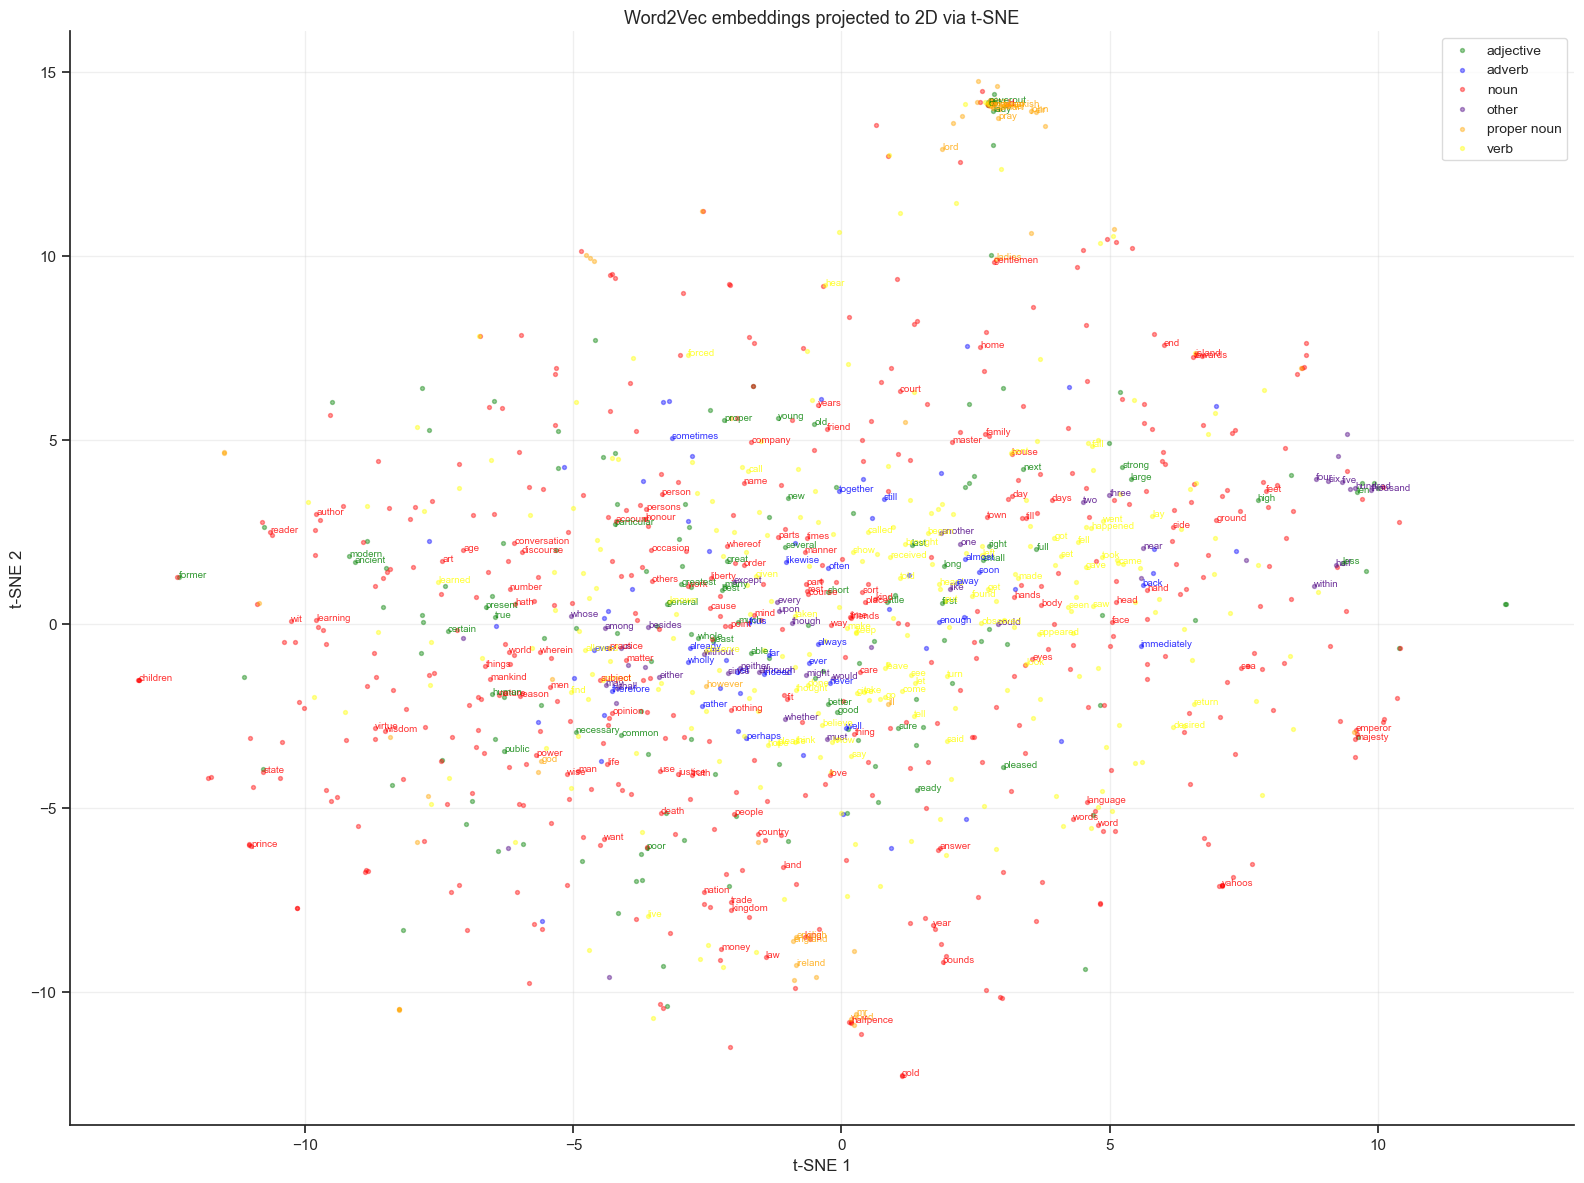

In [76]:
def plot_tsne(coords, figsize=(16, 12), label_top_n=300, save_path=None):
    fig, ax = plt.subplots(figsize=figsize)

    pos_colors = {
        'noun':        'red',
        'proper noun': 'orange',
        'verb':        'yellow',
        'adjective':   'green',
        'adverb':      'blue',
        'other':       'indigo',
    }

    for grp, sub in coords.groupby('pos_group'):
        ax.scatter(sub.x, sub.y, s=8, alpha=0.4,
                   color=pos_colors.get(grp, 'gray'), label=grp)

    top = coords.nlargest(label_top_n, 'n')
    for _, row in top.iterrows():
        ax.annotate(row.term_str, (row.x, row.y),
                    fontsize=7, alpha=0.8,
                    color=pos_colors.get(row.pos_group, 'gray'))

    ax.set_xlabel('t-SNE 1', fontsize=12)
    ax.set_ylabel('t-SNE 2', fontsize=12)
    ax.set_title('Word2Vec embeddings projected to 2D via t-SNE', fontsize=13)
    ax.legend(loc='best', fontsize=10, frameon=True, edgecolor='lightgray')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_tsne(coords, save_path=f"{F5_path}/word2vec/figures/w2v_tsne.png")

## Semantic Algebra

In [77]:
def complete_analogy(A, B, C, n=3):
    try:
        return model.wv.most_similar(positive=[B, C], negative=[A])[0:n]
    except KeyError as e:
        print('Error:', e)
        return None

In [78]:
print("man : woman :: king : ?")
print(complete_analogy('man', 'woman', 'king'))

print("\nireland : kingdom :: england : ?")
print(complete_analogy('ireland', 'kingdom', 'england'))

print("\nlord : king :: lady : ?")
print(complete_analogy('lord', 'king', 'lady'))

print("\nhorse : reason :: man : ?")
print(complete_analogy('horse', 'reason', 'man'))

man : woman :: king : ?
[('queen', 0.4884364902973175), ('metropolis', 0.43535587191581726), ('ordered', 0.42523106932640076)]

ireland : kingdom :: england : ?
[('pounds', 0.5989700555801392), ('english', 0.5525064468383789), ('pay', 0.5464497804641724)]

lord : king :: lady : ?
[('england', 0.5224299430847168), ('queen', 0.5203760862350464), ('kings', 0.5168789625167847)]

horse : reason :: man : ?
[('power', 0.6167310476303101), ('certainly', 0.5931007266044617), ('nature', 0.5669937133789062)]


In [79]:
embedding_df = pd.DataFrame(
    [model.wv.get_vector(w) for w in vocab_terms],
    index=vocab_terms,
    columns=[f'd{i}' for i in range(VECTOR_SIZE)]
)
embedding_df.index.name = 'term_str'

embedding_df.to_csv(f"{F5_path}/word2vec/W2V_embeddings.csv")
coords[['term_str','x','y','pos_group','n']].to_csv(f"{F5_path}/word2vec/W2V_tsne_coords.csv", index=False)

model.save(f"{F5_path}/word2vec/W2V_model.bin")